In [8]:
import fastf1
print ("FastF1 is ready to go!")

FastF1 is ready to go!


In [14]:
import os
os.makedirs ( 'cache', exist_ok=True)
fastf1.Cache.enable_cache ('cache')

In [15]:
session = fastf1.get_session (2026, 1, 'R')
session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

In [19]:
results = session. results
print (results[['DriverNumber', 'FullName', 'Position', 'Points']])

   DriverNumber           FullName  Position  Points
63           63     George Russell       1.0    25.0
12           12     Kimi Antonelli       2.0    18.0
16           16    Charles Leclerc       3.0    15.0
44           44     Lewis Hamilton       4.0    12.0
1             1       Lando Norris       5.0    10.0
3             3     Max Verstappen       6.0     8.0
87           87     Oliver Bearman       7.0     6.0
41           41     Arvid Lindblad       8.0     4.0
5             5  Gabriel Bortoleto       9.0     2.0
10           10       Pierre Gasly      10.0     1.0
31           31       Esteban Ocon      11.0     0.0
23           23    Alexander Albon      12.0     0.0
30           30        Liam Lawson      13.0     0.0
43           43   Franco Colapinto      14.0     0.0
55           55       Carlos Sainz      15.0     0.0
11           11       Sergio Perez      16.0     0.0
18           18       Lance Stroll      17.0     0.0
14           14    Fernando Alonso      18.0  

In [25]:

races = {}
for round_num in [1,2,3]:
    session = fastf1.get_session(2026, round_num, 'R')
    session.load()
    races[round_num] = session
    print(f"Round {round_num} loaded!")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_contr

Round 1 loaded!


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req       

Round 2 loaded!


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']


Round 3 loaded!


In [30]:
import pandas as pd

all_results = []

for round_num in [1,2,3]:
    result = races[round_num].results[['FullName', 'TeamName', 'Position', 'Points']]
    result = result.copy()
    result['Round'] = round_num
    all_results.append(result)

combined = pd.concat(all_results)
print(combined)

           FullName      TeamName  Position  Points  Round
63   George Russell      Mercedes       1.0    25.0      1
12   Kimi Antonelli      Mercedes       2.0    18.0      1
16  Charles Leclerc       Ferrari       3.0    15.0      1
44   Lewis Hamilton       Ferrari       4.0    12.0      1
1      Lando Norris       McLaren       5.0    10.0      1
..              ...           ...       ...     ...    ...
14  Fernando Alonso  Aston Martin      18.0     0.0      3
77  Valtteri Bottas      Cadillac      19.0     0.0      3
23  Alexander Albon      Williams      20.0     0.0      3
18     Lance Stroll  Aston Martin      21.0     0.0      3
87   Oliver Bearman  Haas F1 Team      22.0     0.0      3

[66 rows x 5 columns]


In [32]:
standings = combined.groupby('FullName')['Points'].sum()
standings = standings.sort_values(ascending=False)
print(standings)

FullName
Kimi Antonelli       68.0
George Russell       55.0
Charles Leclerc      42.0
Lewis Hamilton       35.0
Lando Norris         20.0
Oscar Piastri        18.0
Oliver Bearman       16.0
Pierre Gasly         15.0
Max Verstappen       12.0
Liam Lawson           8.0
Arvid Lindblad        4.0
Isack Hadjar          4.0
Gabriel Bortoleto     2.0
Carlos Sainz          2.0
Esteban Ocon          1.0
Franco Colapinto      1.0
Fernando Alonso       0.0
Alexander Albon       0.0
Lance Stroll          0.0
Nico Hulkenberg       0.0
Sergio Perez          0.0
Valtteri Bottas       0.0
Name: Points, dtype: float64


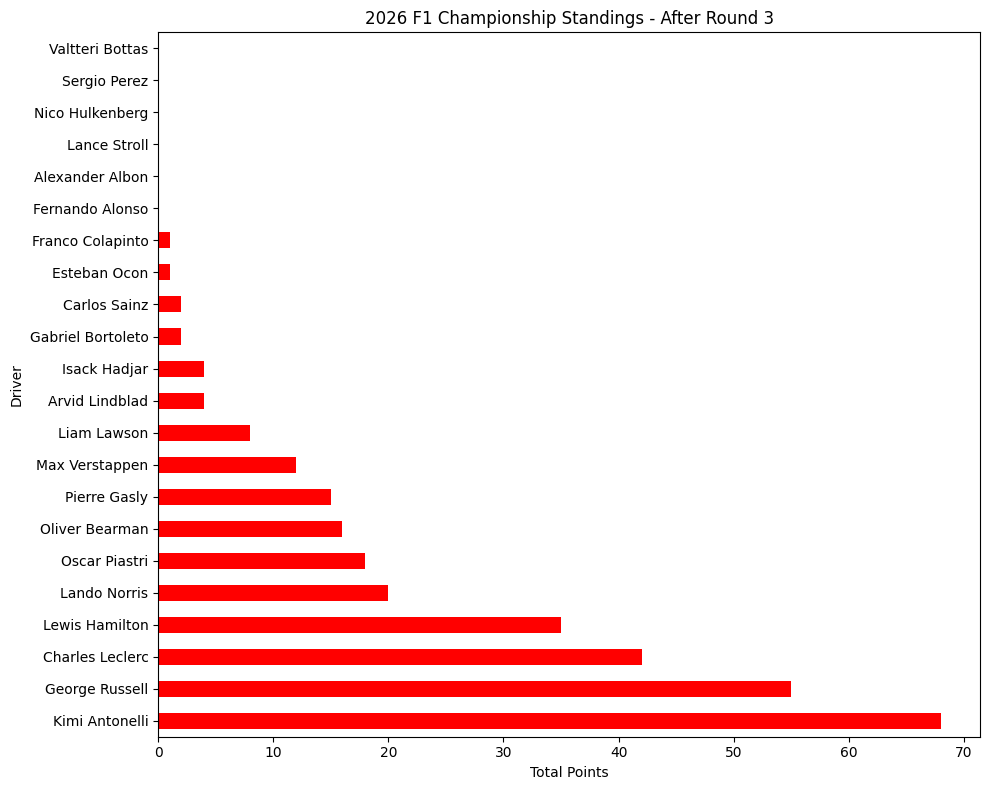

In [35]:
import matplotlib.pyplot as plt

standings.plot(kind='barh', figsize=(10,8), color='red')
plt.title('2026 F1 Championship Standings - After Round 3')
plt.xlabel('Total Points')
plt.ylabel('Driver')
plt.tight_layout()
plt.show() 

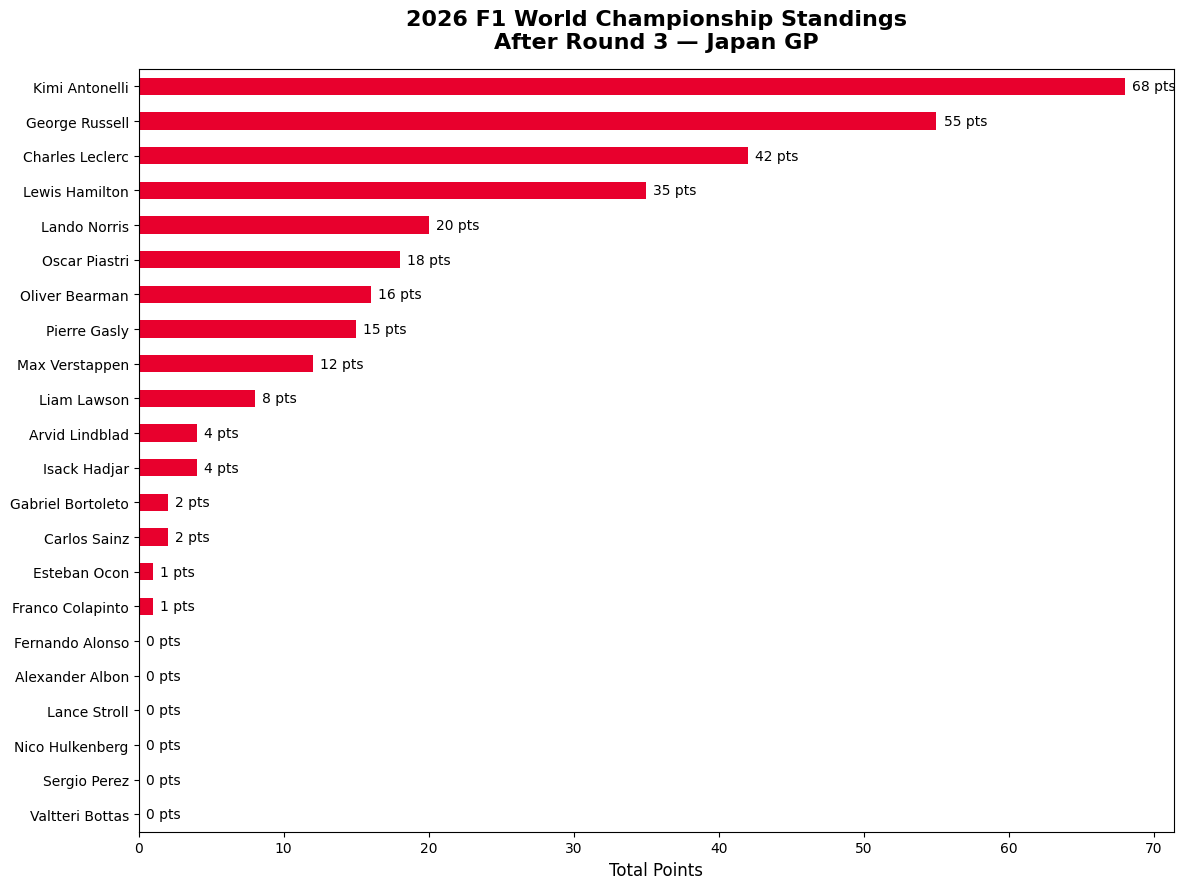

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 9))

colors = ['gold' if i == 0 else 'silver' if i == 1 else 'chocolate' if i == 2 else '#E8002D' for i in range(len(standings))]

standings.plot(kind='barh', ax=ax, color=colors[::-1])

ax.set_title('2026 F1 World Championship Standings\nAfter Round 3 — Japan GP', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Points', fontsize=12)
ax.set_ylabel('')
ax.invert_yaxis()

for i, (name, points) in enumerate(standings.items()):
    ax.text(points + 0.5, i, f'{int(points)} pts', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('championship_standings.png', dpi=150, bbox_inches='tight')
plt.show()

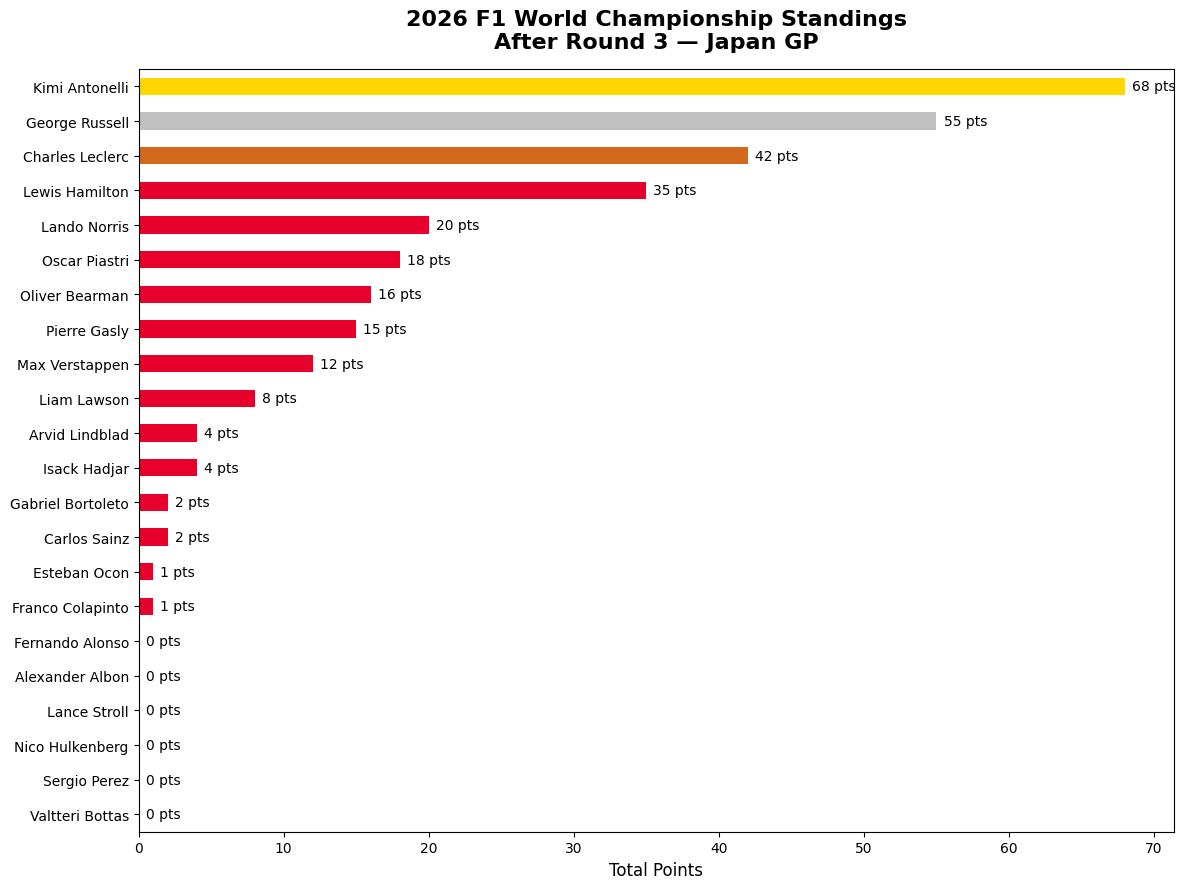

In [37]:
fig, ax = plt.subplots(figsize=(12, 9))

colors = []
for i in range(len(standings)):
    if i == 0:
        colors.append('gold')
    elif i == 1:
        colors.append('silver')
    elif i == 2:
        colors.append('chocolate')
    else:
        colors.append('#E8002D')

standings_reversed = standings.iloc[::-1]
colors_reversed = colors[::-1]

standings_reversed.plot(kind='barh', ax=ax, color=colors_reversed)

ax.set_title('2026 F1 World Championship Standings\nAfter Round 3 — Japan GP',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Points', fontsize=12)
ax.set_ylabel('')

for i, (name, points) in enumerate(standings_reversed.items()):
    ax.text(points + 0.5, i, f'{int(points)} pts', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('championship_standings.png', dpi=150, bbox_inches='tight')
plt.show()